# Exploring Data Sources for Agri-Weather-Yield Drivers

Goal: a first evaluation of publicly available data sources for pipeline inputs to asseess the constraints of our analysis and support our decision which data source to investigate further and consider for the pipeline automation, so we can infer a data schema/contract. This should provide the data contract for the ingest pipeline or a data catalog store.

Need to understand the data structure first.

We'll first consider:

Layer|What we need|Candidate sources
-----|------------|-----------------
**Weather**|Daily `precip_mm`, `tmean_c` per region, 2010–present|DWD open data (FTP), ERA5, E-OBS
**Soil**|`sand_pct_mean` per region |SoilGrids 250m, ESDAC, SoilWeb
**Yield**|Annual `yield_t_ha` by crop and NUTS region | Eurostat `apro_cpsh1`, Destatis

German administrative context: the first iteration/MVP uses Brandenburg (`DE-BB`), Saxony-Anhalt (`DE-ST`),
and Berlin (`DE-BE`) as stand-in NUTS1 regions. The goal is NUTS3 `LAU` crop districts in a 2nd iteration.


## Prerequisites: Depedency Check and Installation

In [1]:
import os, importlib, subprocess, sys
import warnings

# Check for venv and activate if present
# 1. Determine which venv dir:
venv_dir = None
for candidate in ["venv", ".venv"]:
    if os.path.exists(candidate):
        venv_dir = candidate
        break

REQUIRED = ["requests", "geopandas", "folium", "plotly", "pandas", "numpy", "matplotlib"]
missing = [p for p in REQUIRED if importlib.util.find_spec(p) is None]
if missing:
    print("Installing:", missing)
    # If uv is installed, use it for package installation
    if os.system("which uv > /dev/null") == 0:
        print("Using uv for package installation")
        subprocess.check_call(["uv", "add", "--group", "notebooks", *REQUIRED])
    elif venv_dir and os.path.exists(f"{venv_dir}/bin/activate_this.py"):
        print("Activating virtual environment")
        with open(f"{venv_dir}/bin/activate_this.py") as data_feats:
            exec(data_feats.read(), {"__file__": f"{venv_dir}/bin/activate_this.py"})
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    else:
        print(f"Using non-venv Python {sys.version} at {sys.executable}")
        # subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All packages present ✓")


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

All packages present ✓


In [2]:
import json, io, zipfile, urllib.request
from pathlib import Path
import datetime as dt

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium

print("pandas", pd.__version__, "| geopandas", gpd.__version__)
print("folium", folium.__version__)


pandas 3.0.1 | geopandas 1.1.2
folium 0.20.0


## 1. Regional Boundaries (NUTS)

Need polygon geometries for each `region_id` to:

1. spatially assign DWD weather stations to regions
2. aggregate raster soil data to region means
3. display risk maps



### GADM

Let's see if [GADM](https://gadm.org) gives us the necessary polygons.

- GADM level-1 for Germany: https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_DEU_1.json
- ~4 MB so pull metadata first

In [3]:
GADM_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_DEU_1.json"

resp = requests.get(GADM_URL, timeout=15, stream=True)
resp.raise_for_status()
# Read just enough to see the structure without pulling the whole 4 MB
raw_head = b""
for chunk in resp.iter_content(chunk_size=4 * 1024):
    raw_head += chunk
    if len(raw_head) > 8 * 1024:
        break
resp.close()


In [4]:
# Quick peek
raw_head.decode("utf-8", errors="replace")[:600]

'{"type":"FeatureCollection","name":"gadm41_DEU_1","crs":{"type":"name","properties":{"name":"urn:ogc:def:crs:OGC:1.3:CRS84"}},"features":[{"type":"Feature","properties":{"GID_1":"DEU.1_1","GID_0":"DEU","COUNTRY":"Germany","NAME_1":"Baden-Württemberg","VARNAME_1":"NA","NL_NAME_1":"NA","TYPE_1":"Land","ENGTYPE_1":"State","CC_1":"08","HASC_1":"DE.BW","ISO_1":"NA"},"geometry":{"type":"MultiPolygon","coordinates":[[[[8.35,47.5706],[8.3284,47.5712],[8.3221,47.5739],[8.3108,47.5832],[8.3006,47.587],[8.2953,47.5938],[8.2975,47.6057],[8.289,47.6102],[8.279,47.6117],[8.265,47.6095],[8.2602,47.6148],[8.2'

**Problem with GADM for this project:**
- GADM level-1 IDs are different (`DEU.3_1` for Brandenburg) — not NUTS codes
- GADM level-3 (districts) is ~50 MB compressed
- Property names differ across GADM versions; no stable `region_id` key we can use
- No direct link to Eurostat's yield tables which use NUTS codes




### Eurostat GISCO

**Alternative: Eurostat GISCO** — official EU statistical boundary service, gives NUTS polygons
with `NUTS_ID` codes (`DE40` = Brandenburg, `DED` = Saxony-Anhalt, etc.) that join directly to Eurostat crop stats.


Eurostat GISCO: NUTS 2021, level-1, 1:3M scale — small file, for regional overview
https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_03M_2021_4326_LEVL_1.geojson

In [5]:
GISCO_NUTS1 = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_03M_2021_4326_LEVL_1.geojson"

resp = requests.get(GISCO_NUTS1, timeout=20)
resp.raise_for_status()

# GeoJSON -> GeoPandas df
nuts1 = gpd.read_file(io.StringIO(resp.text))
nuts1.columns


Index(['NUTS_ID', 'LEVL_CODE', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME',
       'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'geometry'],
      dtype='str')

In [6]:
de_nuts1 = nuts1[nuts1["CNTR_CODE"] == "DE"].sort_values(["NUTS_ID"]).copy()
de_nuts1.head(4)

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
16,DE1,1,DE,Baden-Württemberg,Baden-Württemberg,0,0,0,"MULTIPOLYGON (((9.64874 49.79148, 9.63197 49.6..."
17,DE2,1,DE,Bayern,Bayern,0,0,0,"POLYGON ((10.10962 50.56292, 10.14029 50.54473..."
27,DE3,1,DE,Berlin,Berlin,0,0,0,"POLYGON ((13.42098 52.37625, 13.39269 52.37854..."
18,DE4,1,DE,Brandenburg,Brandenburg,0,0,0,"MULTIPOLYGON (((13.87281 53.5034, 13.88149 53...."


NUTS-1 features for Germany:

In [7]:
de_nuts1[["NUTS_ID", "NUTS_NAME"]]

,NUTS_ID,NUTS_NAME
16,DE1,Baden-Württemberg
17,DE2,Bayern
27,DE3,Berlin
18,DE4,Brandenburg
19,DE5,Bremen
20,DE6,Hamburg
21,DE7,Hessen
0,DE8,Mecklenburg-Vorpommern
1,DE9,Niedersachsen
2,DEA,Nordrhein-Westfalen


We'll focus on Berlin, Brandenburg, Sachesn-Anhalt - that's DE3, DE4, and DEE.

At NUTS1, Germany has 16 federal states. For crop yield work we need NUTS3 (Landkreise / districts).

Pull NUTS3 for a quick look at granularity.

In [8]:
GISCO_NUTS3 = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_03M_2021_4326_LEVL_3.geojson"

resp = requests.get(GISCO_NUTS3, timeout=30)
resp.raise_for_status()

# GeoJSON -> GeoPandas df
nuts3 = gpd.read_file(io.StringIO(resp.text))
de_nuts3 = nuts3[nuts3["CNTR_CODE"] == "DE"].copy()
de_nuts3.columns


Index(['NUTS_ID', 'LEVL_CODE', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME',
       'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'geometry'],
      dtype='str')


Our focus states: Berlin (DE3x), Brandenburg (DE4x), and Saxony-Anhalt (DEEx)

In [9]:
focus_nuts3 = de_nuts3[de_nuts3["NUTS_ID"].str.startswith(("DE3", "DE4", "DEE"))].copy()
focus_nuts3.head(3)

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
103,DE401,3,DE,"Brandenburg an der Havel, Kreisfreie Stadt","Brandenburg an der Havel, Kreisfreie Stadt",4,2,3,"MULTIPOLYGON (((12.71631 52.52503, 12.70975 52..."
104,DE402,3,DE,"Cottbus, Kreisfreie Stadt","Cottbus, Kreisfreie Stadt",4,2,3,"POLYGON ((14.27283 51.79518, 14.27385 51.8033,..."
105,DE403,3,DE,"Frankfurt (Oder), Kreisfreie Stadt","Frankfurt (Oder), Kreisfreie Stadt",4,2,3,"POLYGON ((14.60089 52.27205, 14.57169 52.27591..."


In [10]:
print(f"NUTS-3 features for Germany: {len(de_nuts3)}")
print(f"Focus region NUTS-3 districts: {len(focus_nuts3)}")

NUTS-3 features for Germany: 401
Focus region NUTS-3 districts: 33


In [11]:
focus_nuts3[["NUTS_ID", "NUTS_NAME"]].sort_values("NUTS_ID")

,NUTS_ID,NUTS_NAME
238,DE300,Berlin
103,DE401,"Brandenburg an der Havel, Kreisfreie Stadt"
104,DE402,"Cottbus, Kreisfreie Stadt"
105,DE403,"Frankfurt (Oder), Kreisfreie Stadt"
106,DE404,"Potsdam, Kreisfreie Stadt"
107,DE405,Barnim
108,DE406,Dahme-Spreewald
109,DE407,Elbe-Elster
110,DE408,Havelland
210,DE409,Märkisch-Oderland


Now let's render the interesting NUTS3.

In [12]:
# Used across Folium maps for consistent shading
def folium_nuts_style_function(data_feats: ...) -> dict[str, str | float]:
    if data_feats["properties"]["NUTS_ID"].startswith("DE4"):
        fill_color = "#F32121"
    elif data_feats["properties"]["NUTS_ID"].startswith("DEE"):
        fill_color = "#8400FF"
    else:
        fill_color = "#3700FF"

    return {
        "fillColor": fill_color,
        "color": "white",
        "weight": 1,
        "fillOpacity": 0.55,
    }

In [13]:
# Interactive map, chloropleth color by state
m = folium.Map(location=[52.3, 12.5], zoom_start=7, tiles="CartoDB Positron")

if focus_nuts3.geometry.notna().any():
    folium.GeoJson(
        focus_nuts3.__geo_interface__,
        name="NUTS3 of DE3/DE4/DEE",
        style_function=folium_nuts_style_function,
        tooltip=folium.GeoJsonTooltip(fields=["NUTS_ID", "NUTS_NAME"]),
    ).add_to(m)
else:
    folium.Marker([52.5, 13.4], popup="Berlin (no geometry in offline mode)").add_to(m)

folium.LayerControl().add_to(m)
m

## 2. DWD Weather Data

[DWD](https://www.dwd.de/EN/climate_environment/cdc/cdc_node_en.html) (Deutscher Wetterdienst) publishes
daily station observations on a public server under the CDC (Climate Data Center).

- https://www.dwd.de/DE/leistungen/opendata/opendata.html
- https://www.dwd.de/DE/leistungen/opendata/hilfe.html
- https://opendata.dwd.de/README.txt


### `wetterdienst` Python package

- https://pypi.org/project/wetterdienst/
- https://github.com/earthobservations/wetterdienst

In [14]:
# %pip install wetterdienst
# %uv add --package notebooks wetterdienst


There's a `wetterdienst` Python package that wraps the DWD API.  

```py
# pip install wetterdienst
from wetterdienst.provider.dwd.observation import DwdObservationRequest
```

But: **too heavy here**: The package pulls 15+ [transitive dependencies](https://github.com/earthobservations/wetterdienst/blob/bc362698e1405edba9ffa6f967e88f881178fe5f/pyproject.toml#L83-L109) (SQLAlchemy, aiohttp, pydantic…) for the [`export`](https://github.com/earthobservations/wetterdienst/blob/bc362698e1405edba9ffa6f967e88f881178fe5f/pyproject.toml#L130-L136) feature, for SQL relies now on DuckDB, also a heavy dependency unless shared across projects. No need to pull in Polars along Pandas here. Overkill for batch ingest of filtered CSVs.

Instead, we'll talk to the DWD open data server directly... first, discover query path structure of the API.

In [15]:
# DWD CDC base — station inventory for precipitation (KL = "Klima", daily observations)
DWD_CDC = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily"

PRECIP_STATIONS_URL = f"{DWD_CDC}/kl/recent/KL_Tageswerte_Beschreibung_Stationen.txt"

resp = requests.get(PRECIP_STATIONS_URL, timeout=20)
resp.raise_for_status()

# Fixed-width, German encoding
raw = resp.content.decode("latin-1")
print("First 1k chars of station list:")
print(raw[:1000])

First 1k chars of station list:
Stations_id von_datum bis_datum Stationshoehe geoBreite geoLaenge Stationsname Bundesland Abgabe
----------- --------- --------- ------------- --------- --------- ----------------------------------------- ---------- ------
00001 19370101 19860630            478     47.8413    8.8493 Aach                                     Baden-Württemberg                        Frei                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

So there's 9 attributes.

And there are rows like:

```txt
00102 19980101 20260228              0     53.8633    8.1275 Leuchtturm Alte Weser                    Niedersachsen                            Frei
00106 19710101 20061201            500     51.7976   10.4429 Altenau                                  Niedersachsen
00116 18990601 19730531            213     50.9833   12.4333 Altenburg                                Thüringen                                Frei

```

i.e., with a missing `Abgabe` attribute.

We'll parse that fixed-width file with Pandas, cf. https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html.


In [16]:
dwd_header = raw[:256].split("\n")[0].strip().split()
dwd_header

['Stations_id',
 'von_datum',
 'bis_datum',
 'Stationshoehe',
 'geoBreite',
 'geoLaenge',
 'Stationsname',
 'Bundesland',
 'Abgabe']

In [17]:
# Rename for convenience
dwd_cols = ["station_id", "date_from", "date_to", "elevation_m", "lat", "lon", "name", "bundesland", "extra"]

In [18]:
dwd_stations_df = pd.read_fwf(
    # PRECIP_STATIONS_URL,
    io.StringIO(raw),
    encoding="latin-1",
    names=dwd_cols,
    skiprows=2,
    index_col=0,
    parse_dates=["date_from", "date_to"],
    dtype={"extra": "category", "station_id": str},
)
dwd_stations_df

,date_from,date_to,elevation_m,lat,lon,name,bundesland,extra
station_id,,,,,,,,
00001,1937-01-01,1986-06-30,478,47.8413,8.8493,Aach,Baden-Württemberg,Frei
00003,1891-01-01,2011-03-31,202,50.7827,6.0941,Aachen,Nordrhein-Westfalen,Frei
00011,1980-09-01,2026-03-07,680,47.9736,8.5205,Donaueschingen (Landeplatz),Baden-Württemberg,Frei
00044,1969-01-01,2026-03-07,44,52.9336,8.2370,Großenkneten,Niedersachsen,Frei
00052,1969-01-01,2001-12-31,46,53.6623,10.1990,Ahrensburg-Wulfsdorf,Schleswig-Holstein,Frei
...,...,...,...,...,...,...,...,...
19985,1981-01-01,2003-12-31,455,48.8457,8.9073,Weissach/Strudelbach,Baden-Württemberg,Frei
19989,1936-01-01,2012-06-30,147,50.0681,8.2603,Wiesbaden (Südost),Hessen,Frei
20007,1882-01-01,1915-12-31,332,50.8422,12.8770,Chemnitz-Altendorf,Sachsen,Frei


In [19]:
# Filter our just three bundeslaender
dwd_stations_focus_df = dwd_stations_df[dwd_stations_df["bundesland"].isin(["Berlin", "Brandenburg", "Sachsen-Anhalt"])]

In [20]:
dwd_stations_focus_df.sort_values(["bundesland", "name"]).head(10)

,date_from,date_to,elevation_m,lat,lon,name,bundesland,extra
station_id,,,,,,,,
00395,1948-07-01,1953-12-31,38,52.4167,13.4833,Berlin-Adlershof,Berlin,Frei
00399,1975-01-01,2015-06-30,36,52.5198,13.4057,Berlin-Alexanderplatz,Berlin,Frei
00400,1951-01-01,2026-03-07,60,52.6310,13.5021,Berlin-Buch,Berlin,Frei
00403,1950-01-01,2026-03-07,51,52.4537,13.3017,Berlin-Dahlem (FU),Berlin,Frei
00402,1876-01-01,1962-12-31,55,52.4564,13.2997,Berlin-Dahlem (LFAG),Berlin,Frei
00405,1951-04-01,1954-12-31,37,52.4500,13.6500,Berlin-Friedrichshagen,Berlin,Frei
00407,1958-01-01,1978-03-31,48,52.6461,13.2858,Berlin-Frohnau,Berlin,Frei
00408,1948-12-01,1951-11-30,35,52.5333,13.3833,Berlin-Invalidenstraße,Berlin,Frei
00410,1996-06-01,2020-06-15,33,52.4040,13.7309,Berlin-Kaniswall,Berlin,Frei


In [21]:
dwd_stations_focus_df.nunique(0), len(dwd_stations_focus_df)

(date_from      100
 date_to         62
 elevation_m     92
 lat            125
 lon            126
 name           128
 bundesland       3
 extra            1
 dtype: int64,
 128)

In [22]:
dwd_stations_focus_df.get("bundesland", pd.Series(dtype=str)).str.contains(
    "Berlin|Brandenburg|Sachsen-Anhalt", na=False
)


station_id
00096    True
00164    True
00181    True
00184    True
00207    True
         ... 
07364    True
07389    True
07420    True
14138    True
19940    True
Name: bundesland, Length: 128, dtype: bool

So for the 1st iteration, we'll focus on just 128 stations across Berlin, Brandenburg, and Saxony-Anhalt.

In [23]:
# Same view as above but interactive — folium lets us hover/zoom
m2 = folium.Map(location=[52.3, 12.5], zoom_start=7, tiles="CartoDB Positron")

# NUTS3 boundaries as background
if focus_nuts3.geometry.notna().any():
    folium.GeoJson(
        focus_nuts3.__geo_interface__,
        name="NUTS3 districts",
        style_function=folium_nuts_style_function,
        tooltip=folium.GeoJsonTooltip(fields=["NUTS_ID", "NUTS_NAME"]),
    ).add_to(m2)

# DWD station markers with offset labels
for _, row in dwd_stations_focus_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=2,
        color="#009900",
        fill=True,
        fill_color="#00bb00",
        fill_opacity=0.8,
        tooltip=f"{row['name']} ({row.get('bundesland', '?')})",
    ).add_to(m2)

    # Offset text label (DivIcon placed slightly to the right of the marker)
    folium.Marker(
        location=[row["lat"], row["lon"]],
        icon=folium.DivIcon(
            icon_size=(120, 14),
            icon_anchor=(-6, 7),  # shift label right and vertically centre
            html=f'<span style="font-size:9px;color:#333;white-space:nowrap">{row["name"]}</span>',
        ),
    ).add_to(m2)

folium.LayerControl().add_to(m2)
m2

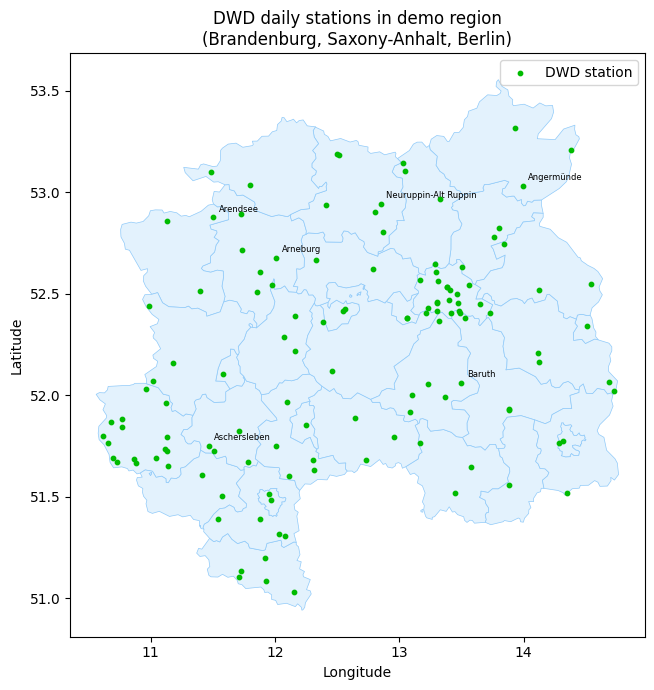

In [24]:
# Plot stations on top of NUTS-3 boundaries (Matplotlib as static fallback).
fig, ax = plt.subplots(figsize=(8, 7))

if focus_nuts3.geometry.notna().any():
    focus_nuts3.plot(ax=ax, color="#E3F2FD", edgecolor="#90CAF9", linewidth=0.5)

# Plot station points
ax.scatter(
    dwd_stations_focus_df["lon"], dwd_stations_focus_df["lat"], s=10, color="#00bb00", zorder=5, label="DWD station"
)
for _, row in dwd_stations_focus_df.head(6).iterrows():
    ax.annotate(row["name"], (row["lon"], row["lat"]), fontsize=6, xytext=(4, 4), textcoords="offset points")

ax.set_title("DWD daily stations in demo region\n(Brandenburg, Saxony-Anhalt, Berlin)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

plt.tight_layout()
plt.show()

### A station-to-region mapping problem

DWD data is **point-based** (stations), our pipeline is **region-based** (NUTS polygons).

Options from simplest to most correct:

Approach|Effort|Bias
--------|------|----
Nearest-station to NUTS centroid | Low | High if region is large
All stations within polygon -> area-weighted mean | Medium | Lower
Kriging / spatial interpolation | High | Lowest
Pre-gridded product (E-OBS, ERA5) -> zonal mean | Low | Depends on reanalysis quality

**For the 1st iteration let's delegate this step to the ingest preprocessing:**
the pipeline assumes a caller has already produced a CSV with one row per `(region_id, date)`, matching our schema:

```py
WEATHER_DAILY_COLUMNS = {"date", "region_id", "precip_mm", "tmean_c"}
```

This is exactly what `dwd_parse.py::read_daily_weather_csv` expects.

The spatial aggregation logic is left documented for a later iteration.

Now, peek at the actual DWD zip format for just one station (e.g., Potsdam, id=03946, long history).

- The KL (Klima) daily zips contain: `Metadaten_*.txt` files + `produkt_klima_tag_*.txt`.
- Each zip is ~100-200 KB.

PROBLEM: DWD filenames encode the station's date range, which changes as new data is published.

```txt
e.g.,  tageswerte_KL_03946_19010101_20231231_akt.zip -> becomes
       tageswerte_KL_03946_19010101_20241231_akt.zip    next year (_2023 -> _2024)
```

Can't hardcode a stable URL - must either scrape the directory listing or use the heavy `wetterdienst` package.

This is another argument for using a pre-processed CSV as the pipeline's ingest contract.

Let's fetch the remote directory contents as HTML and quickly regex-extract the zip file name for, e.g., Potsdam only.

In [25]:
import re

DWD_KL_HISTORICAL = f"{DWD_CDC}/kl/historical"

station_id = "03946"  # Potsdam

dir_resp = requests.get(DWD_KL_HISTORICAL + "/", timeout=10)
dir_resp.raise_for_status()

# Match only the zip filename, stop at first quote or >  (DWD uses href="name">name links)
matches = re.findall(f"tageswerte_KL_{station_id}_" + r'[0-9_a-z]+\.zip(?=")', dir_resp.text)
if not matches:
    # broader fallback
    matches = re.findall(f"(tageswerte_KL_{station_id}_" + r"[\w]+\.zip)", dir_resp.text)

# Potsdam zip file found:
if matches:
    POTSDAM_ZIP = f"{DWD_KL_HISTORICAL}/{matches[0]}"
    print(f"Found file: {matches[0]}")

    # Now fetch it
    resp = requests.get(POTSDAM_ZIP, timeout=30)
    resp.raise_for_status()

    # And peek inside the zip file
    z = zipfile.ZipFile(io.BytesIO(resp.content))
    print("Files in zip:", z.namelist())

    # We need just this one:
    data_file = next(n for n in z.namelist() if n.startswith("produkt_klima"))
    raw_data = z.read(data_file).decode("latin-1")
    print()
    # Quick preview:
    for line in raw_data.splitlines()[:5]:
        print(line)
else:
    raise ValueError("Station 03946 not found in directory listing")

Found file: tageswerte_KL_03946_18820101_20241231_hist.zip
Files in zip: ['Metadaten_Geraete_Luftdruck_Stationshoehe_03946.html', 'Metadaten_Geraete_Luftdruck_Stationshoehe_03946.txt', 'Metadaten_Stationsname_Betreibername_03946.html', 'Metadaten_Stationsname_Betreibername_03946.txt', 'Metadaten_Parameter_klima_tag_03946.html', 'Metadaten_Parameter_klima_tag_03946.txt', 'Metadaten_Geraete_Lufttemp_Am_Erdb_Minimum_03946.html', 'Metadaten_Geraete_Lufttemp_Am_Erdb_Minimum_03946.txt', 'Metadaten_Geraete_Lufttemperatur_03946.html', 'Metadaten_Geraete_Lufttemperatur_03946.txt', 'Metadaten_Geraete_Lufttemperatur_Maximum_03946.html', 'Metadaten_Geraete_Lufttemperatur_Maximum_03946.txt', 'Metadaten_Geraete_Lufttemperatur_Minimum_03946.html', 'Metadaten_Geraete_Lufttemperatur_Minimum_03946.txt', 'Metadaten_Geraete_Niederschlagshoehe_03946.html', 'Metadaten_Geraete_Niederschlagshoehe_03946.txt', 'Metadaten_Geraete_Niederschlagshoehe_Ind_03946.html', 'Metadaten_Geraete_Niederschlagshoehe_Ind_03946

So it's a CSV file with the European/German semicolon convention. Let's parse it as a Pandas df.

In [26]:
import io

dwd_cdc_potsdam_df = pd.read_csv(
    io.StringIO(raw_data),
    encoding="latin-1",
    # names=dwd_cdc_potsdam_cols,
    header=0,
    index_col=[0, 1],
    sep=";",
    parse_dates=["MESS_DATUM"],
    dtype={"eor": "category", "STATIONS_ID": str},
    na_values=[-999],  # 150 year old measurements likely incomplete, by today's schema, hence -999 sentinel value.
)
dwd_cdc_potsdam_df

QN_3    FX    FM  QN_4   RSK  RSKF   SDK  SHK_TAG  \
STATIONS_ID MESS_DATUM                                                      
3946        1882-01-01   NaN   NaN   NaN     1   0.0   1.0   NaN      0.0   
            1882-01-02   NaN   NaN   NaN     1   0.0   0.0   NaN      0.0   
            1882-01-03   NaN   NaN   NaN     1   0.0   1.0   NaN      0.0   
            1882-01-04   NaN   NaN   NaN     1   0.0   0.0   NaN      0.0   
            1882-01-05   NaN   NaN   NaN     1   0.5   1.0   NaN      0.0   
...                      ...   ...   ...   ...   ...   ...   ...      ...   
            2024-12-27  10.0   3.3   0.9     9   0.0   0.0   NaN      0.0   
            2024-12-28  10.0   6.4   1.9     9   0.0   0.0   NaN      0.0   
            2024-12-29  10.0   9.3   3.3     9   0.0   0.0   NaN      0.0   
            2024-12-30  10.0  11.6   4.4     9   0.0   8.0   NaN      0.0   
            2024-12-31  10.0  13.2   4.5     9   0.0   0.0   NaN      0.0   

                          NM   VPM     PM   TMK   UPM   TXK   TNK   TGK  eor  
STATIONS_ID MESS_DATUM                                                        
3946        1882-01-01   2.3   4.0  973.9  -3.7  85.0   0.0  -8.0   NaN  eor  
            1882-01-02   4.7   5.3  971.1   1.1  80.0   4.0  -6.0   NaN  eor  
            1882-01-03   6.0   6.4  961.4   6.3  67.0   7.5   2.0   NaN  eor  
            1882-01-04   7.3   6.8  967.3   4.1  82.0   7.0   2.4   NaN  eor  
            1882-01-05   4.7   5.2  973.5   1.5  75.0   5.0  -3.5   NaN  eor  
...                      ...   ...    ...   ...   ...   ...   ...   ...  ...  
            2024-12-27   5.5   4.6  987.3  -1.2  83.0   6.0  -5.1  -7.2  eor  
            2024-12-28   0.1   4.5  983.1   0.3  74.0   8.1  -4.7  -6.5  eor  
            2024-12-29   3.6   4.5  981.7  -1.9  85.0   0.2  -3.7  -5.4  eor  
            2024-12-30   7.8   4.7  982.8  -1.9  89.0  -1.0  -2.5  -2.7  eor  
            2024-12-31   5.5   4.8  980.3  -0.7  84.0   2.6  -1.9  -3.6  eor  

[51590 rows x 17 columns]

### Synthetic daily weather

Let's try to establish how a properly pre-processed regional daily CSV should look like
 (the output of a data engineering step that resolves station -> region), so we can continue with a shape/contract assumption.

We'll simulate how a correctly-shaped regional CSV looks like for one season:

In [27]:
dates = pd.date_range("2022-10-01", "2022-10-31", freq="D")
(np.tile(np.arange(len(dates)), 3) / 365.25).round(3)

array([0.   , 0.003, 0.005, 0.008, 0.011, 0.014, 0.016, 0.019, 0.022,
       0.025, 0.027, 0.03 , 0.033, 0.036, 0.038, 0.041, 0.044, 0.047,
       0.049, 0.052, 0.055, 0.057, 0.06 , 0.063, 0.066, 0.068, 0.071,
       0.074, 0.077, 0.079, 0.082, 0.   , 0.003, 0.005, 0.008, 0.011,
       0.014, 0.016, 0.019, 0.022, 0.025, 0.027, 0.03 , 0.033, 0.036,
       0.038, 0.041, 0.044, 0.047, 0.049, 0.052, 0.055, 0.057, 0.06 ,
       0.063, 0.066, 0.068, 0.071, 0.074, 0.077, 0.079, 0.082, 0.   ,
       0.003, 0.005, 0.008, 0.011, 0.014, 0.016, 0.019, 0.022, 0.025,
       0.027, 0.03 , 0.033, 0.036, 0.038, 0.041, 0.044, 0.047, 0.049,
       0.052, 0.055, 0.057, 0.06 , 0.063, 0.066, 0.068, 0.071, 0.074,
       0.077, 0.079, 0.082])

In [28]:
EXPECTED_SCHEMA = {
    "date": "YYYY-MM-DD string or date object",
    "region_id": "string matching our NUTS/demo region IDs (e.g. 'DE-BB')",
    "precip_mm": "float ≥ 0, NaN allowed",
    "tmean_c": "float, NaN allowed",
}

dates = pd.date_range("2022-10-01", "2023-07-31", freq="D")

np.random.seed(42)

demo_daily = pd.DataFrame(
    {
        "date": [d.date() for d in dates] * 3,
        "region_id": ["DE-BB"] * len(dates) + ["DE-ST"] * len(dates) + ["DE-BE"] * len(dates),
        "precip_mm": np.clip(np.random.gamma(0.8, 3.0, size=len(dates) * 3), 0, None).round(1),
        "tmean_c": (
            5  # bias
            + 8 * np.sin(2 * np.pi * np.tile(np.arange(len(dates)), 3) / 365.25)  # seasonalilty/cyclicity
            + np.random.normal(0, 2, len(dates) * 3)  # random Gaussian noise (epsilon)
        ).round(2),
    }
)

# Assume: ~35% dry days
demo_daily.loc[np.random.random(len(demo_daily)) < 0.35, "precip_mm"] = 0.0

print(f"Schema: {list(demo_daily.columns)}")
print(f"Shape: {demo_daily.shape} ({demo_daily['region_id'].nunique()} regions × {len(dates)} days)")
demo_daily.head(8)

Schema: ['date', 'region_id', 'precip_mm', 'tmean_c']
Shape: (912, 4) (3 regions × 304 days)


,date,region_id,precip_mm,tmean_c
0,2022-10-01,DE-BB,0.9,7.44
1,2022-10-02,DE-BB,0.0,6.30
2,2022-10-03,DE-BB,0.0,4.82
3,2022-10-04,DE-BB,0.1,3.49
4,2022-10-05,DE-BB,0.0,4.81
5,2022-10-06,DE-BB,0.0,7.86
6,2022-10-07,DE-BB,4.8,9.59
7,2022-10-08,DE-BB,0.4,9.05


#### Sanity check the synthetic daily weather

Before moving on to soil + yields, let's sanity-check the demo data we just built.
Does it look remotely plausible? Any obvious gaps or weirdness?

In [29]:
# Basic shape / types / nulls
demo_daily.dtypes

date          object
region_id        str
precip_mm    float64
tmean_c      float64
dtype: object

In [30]:
demo_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       912 non-null    object 
 1   region_id  912 non-null    str    
 2   precip_mm  912 non-null    float64
 3   tmean_c    912 non-null    float64
dtypes: float64(2), object(1), str(1)
memory usage: 33.1+ KB


In [31]:
demo_daily.isna().sum()  # nulls, n/a

date         0
region_id    0
precip_mm    0
tmean_c      0
dtype: int64

In [32]:
demo_daily.duplicated().sum()  # count duplicate rows

np.int64(0)

In [33]:
# Summary stats per region — does each region have the same coverage?
demo_daily.groupby("region_id")[["precip_mm", "tmean_c"]].describe().round(2)

precip_mm                                        tmean_c        \
              count  mean   std  min  25%  50%   75%   max   count  mean   
region_id                                                                  
DE-BB         304.0  1.47  2.37  0.0  0.0  0.3  2.12  14.0   304.0  5.81   
DE-BE         304.0  1.70  3.07  0.0  0.0  0.5  2.20  23.3   304.0  5.80   
DE-ST         304.0  1.37  2.11  0.0  0.0  0.3  2.10  11.5   304.0  5.77   

                                                 
            std   min   25%   50%    75%    max  
region_id                                        
DE-BB      6.26 -6.73  0.43  7.04  11.29  19.37  
DE-BE      6.20 -6.52 -0.02  6.96  11.06  17.20  
DE-ST      6.24 -7.65 -0.16  6.82  11.23  17.88

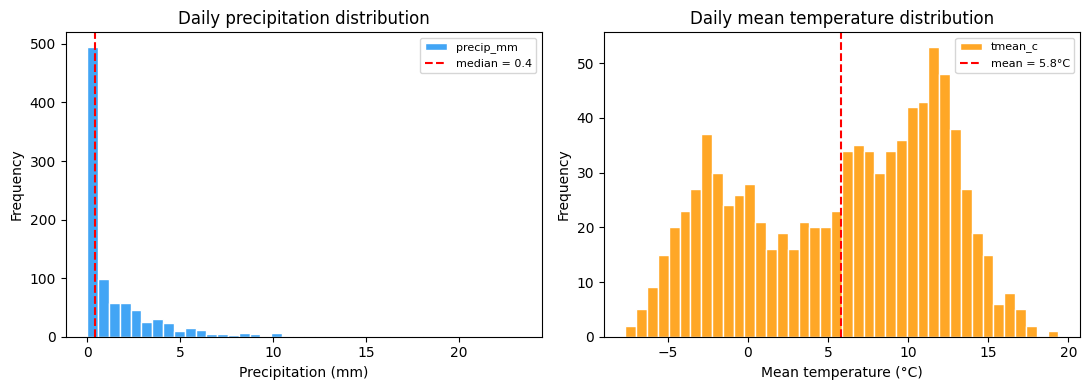

In [34]:
# Distribution of precip and temp - histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Precip - expect right-skewed with a spike at 0
demo_daily["precip_mm"].plot.hist(bins=40, ax=axes[0], color="#42A5F5", edgecolor="white")
axes[0].set_xlabel("Precipitation (mm)")
axes[0].set_title("Daily precipitation distribution")
axes[0].axvline(
    demo_daily["precip_mm"].median(), color="red", ls="--", label=f"median = {demo_daily['precip_mm'].median():.1f}"
)
axes[0].legend(fontsize=8)

# Tmean - should look sinusoidal / normal-ish
demo_daily["tmean_c"].plot.hist(bins=40, ax=axes[1], color="#FFA726", edgecolor="white")
axes[1].set_xlabel("Mean temperature (°C)")
axes[1].set_title("Daily mean temperature distribution")
axes[1].axvline(
    demo_daily["tmean_c"].mean(), color="red", ls="--", label=f"mean = {demo_daily['tmean_c'].mean():.1f}°C"
)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [35]:
f"Zero-precip days: {(demo_daily['precip_mm'] == 0).mean():.1%}"

'Zero-precip days: 39.0%'

In [36]:
f"Days below 0°C: {(demo_daily['tmean_c'] < 0).mean():.1%}"

'Days below 0°C: 25.3%'

Check seasonal shape for Brandenburg

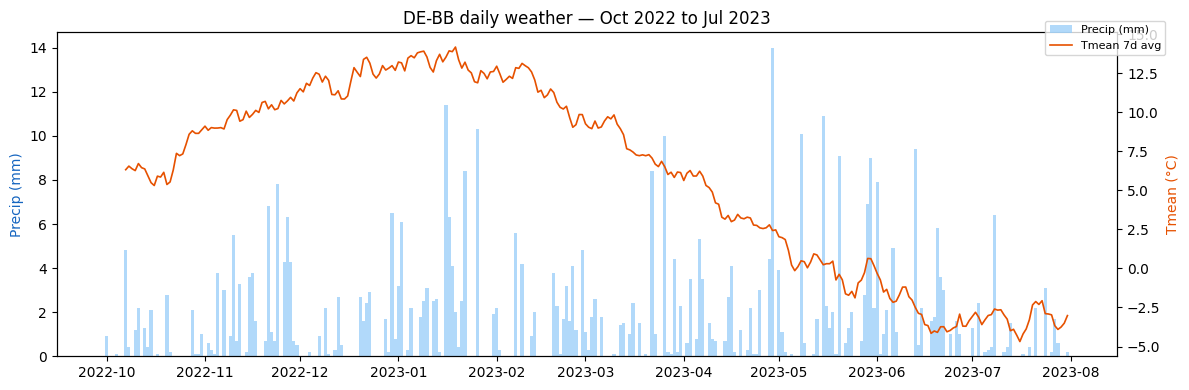

In [37]:
bb = demo_daily[demo_daily["region_id"] == "DE-BB"].copy()
bb["date"] = pd.to_datetime(bb["date"])
bb = bb.set_index("date").sort_index()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(bb.index, bb["precip_mm"], width=1, color="#90CAF9", alpha=0.7, label="Precip (mm)")
ax1.set_ylabel("Precip (mm)", color="#1565C0")

ax2 = ax1.twinx()
ax2.plot(bb.index, bb["tmean_c"].rolling(7).mean(), color="#E65100", linewidth=1.2, label="Tmean 7d avg")
ax2.set_ylabel("Tmean (°C)", color="#E65100")

ax1.set_title("DE-BB daily weather — Oct 2022 to Jul 2023")
fig.legend(loc="upper right", bbox_to_anchor=(0.98, 0.95), fontsize=8)
plt.tight_layout()
plt.show()

The synthetic data set looks plausible. Enough to continue for now.

### Candidate approach 1: rasterio + SoilGrids GeoTIFF

```python
import rasterio
from rasterio.mask import mask as rio_mask
```

rasterio comes in as a transitive dep of `geopandas`. So we can:

1. Request a GeoTIFF tile from SoilGrids WCS for our bounding box
2. Clip to each NUTS3 polygon with `rasterio.mask`
3. Compute `np.nanmean(data / 10)` for `sand_pct_mean`

This gives the **correct** zonal mean (thousands of 250 m pixels per polygon, not just a centroid).

But downloadin the SoilGrids 250m sand GeoTIFF directly and use rasterio
https://files.isric.org/soilgrids/latest/data/sand/SAND_0-5cm_mean.vrt

encumbers us with a ~6 GB global VRT with cloud-optimised GeoTIFFs underneath.

So we'll test the easier REST API first, and note rasterio as the desired integration path.

In [38]:
import rasterio

#### SoilGrids REST API

Query average sand fraction for point locations (centroid per region)

```
https://rest.isric.org/soilgrids/v2.0/properties/query?lon=...&lat=...&property=sand&depth=0-5cm&value=mean
```

In [39]:
SOILGRIDS_URL = "https://rest.isric.org/soilgrids/v2.0/properties/query"

# Approximate centroids for our demo regions
region_centroids = {
    "DE-BB": (13.40, 52.53),  # Brandenburg (centroid ~Potsdam area)
    "DE-BE": (13.40, 52.52),  # Berlin (city-state, agglomeration with Potsdam, so similar to BB centroid)
    "DE-ST": (11.63, 51.90),  # Saxony-Anhalt
}

sand_results: dict[str, float | None] = {}
for region_id, (lon, lat) in region_centroids.items():
    try:
        r = requests.get(
            SOILGRIDS_URL,
            params={"lon": lon, "lat": lat, "property": "sand", "depth": "0-5cm", "value": "mean"},
        )
        r.raise_for_status()
        data = r.json()

        # Path: layers[0].depths[0].values.mean (in g/kg → divide by 10 for %)
        val_g_kg = data["properties"]["layers"][0]["depths"][0]["values"]["mean"]
        if val_g_kg is not None:
            sand_pct: float | None = round(val_g_kg / 10.0, 1)
            print(f"{region_id}: {sand_pct:.1f}% sand (0–5 cm, centroid)")
        else:
            sand_pct = None
            print(f"{region_id}: API returned null — outside soil coverage or request issue")
        sand_results[region_id] = sand_pct
    except Exception as e:
        print(f"{region_id}: [error] {type(e).__name__}: {e}")
        sand_results[region_id] = None

DE-BB: API returned null — outside soil coverage or request issue
DE-BE: API returned null — outside soil coverage or request issue
DE-ST: API returned null — outside soil coverage or request issue


So no coverage for these three regions.


Must fall back to literature values for any None entries:

- ...

In [40]:
LITERATURE_SAND = {"DE-BB": 72.0, "DE-ST": 45.0, "DE-BE": 65.0}
for k in sand_results:
    if sand_results[k] is None:
        sand_results[k] = LITERATURE_SAND[k]
        print(f" - using literature fallback for {k}: {LITERATURE_SAND[k]}%")

print("\nSand fraction used:", sand_results)

 - using literature fallback for DE-BB: 72.0%
 - using literature fallback for DE-BE: 65.0%
 - using literature fallback for DE-ST: 45.0%

Sand fraction used: {'DE-BB': 72.0, 'DE-BE': 65.0, 'DE-ST': 45.0}


Centroid-only query is questionable - the within-region soil heterogeneity can be large.

Brandenburg (DE-BB) is famously sandy (glacial outwash plains) but has pockets of loam.

Better approach: spatial join of SoilGrids 250m raster to NUTS polygon → zonal mean.

- [ ] This requires rasterio or GDAL. For the MVP however we'll just approximate with region-level means.

#### Visual: bar chart of sand % by region

In [41]:
import plotly.graph_objects as go

regions = list(sand_results.keys())
sand_vals = [sand_results[r] for r in regions]

#
fig = go.Figure(
    go.Bar(
        x=regions,
        y=sand_vals,
        marker_color=["#FF8F00" if v and v > 60 else "#66BB6A" for v in sand_vals],
        text=[f"{v}%" if v else "N/A" for v in sand_vals],
        textposition="outside",
    )
)

# risk threshold
fig.add_hline(
    y=60, line_dash="dot", line_color="red", annotation_text="demo risk threshold (60%)", annotation_position="right"
)

#
fig.update_layout(
    title="Sand fraction (0–5 cm depth, regional centroid) — SoilGrids 250m",
    xaxis_title="Region",
    yaxis_title="Sand %",
    yaxis_range=[0, 100],
    height=400,
)
fig.show()

## 4. Yield Statistics

Two natural sources for Germany crop yields at sub-national level:

Source|Granularity|API|Lag|Notes
------|-----------|---|---|----
**Eurostat `apro_cpsh1`** | NUTS2 | REST JSON | ~6 months | Harmonised EU series
**Destatis (Genesis)** | Kreisebene (county) | SOAP/REST | ~4 months | Finest German resolution

We try Eurostat first: open JSON API, no authentication needed. Destatis requires an API key and has `pystatis` package.

#### Eurostat API

- Eurostat REST API: crop harvested production / yield by NUTS2
- Dataset: `apro_cpsh1` - Crop production in EU standard humidity
- Filter: `unit=YLD` (yield, 100 kg/ha) + `crop=C1100` (soft wheat) + DE `nuts2`

Caveat: Eurostat has two incompatible API versions:
- v1 (legacy): single-value `?key=value` params, returns XML or JSON-stat
- v2 (SDMX 2.1): dot-path dataset/filter/key notation, completely different

Mixing them returns 400. The URL below uses v1; dimension key names also changed between releases (e.g. 'crops' vs 'crop_pro'). Check the Data Browser to get exact params.

-> Fallback: download TSV from the Data Browser UI and parse locally for reproducibility.


In [42]:
EUROSTAT_API = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"
params = {
    "format": "JSON",
    "lang": "EN",
    "freq": "A",
    "unit": "YLD",  # yield, 100 kg per ha (divide by 10 → t/ha)
    "crops": "C1100",  # soft wheat (Winterweizen)
    "geo": ["DE4", "DEE", "DE3"],  # Brandenburg, Saxony-Anhalt, Berlin (NUTS2)
    "sinceTimePeriod": "2010",
}

try:
    r = requests.get(f"{EUROSTAT_API}/apro_cpsh1", params=params, timeout=20)
    r.raise_for_status()
    data = r.json()
    dim_time = data["dimension"]["time"]["category"]["index"]
    dim_geo = data["dimension"]["geo"]["category"]["index"]
    n_time = len(dim_time)
    values = data["value"]

    rows = []
    for geo_label, gi in dim_geo.items():
        for time_label, ti in dim_time.items():
            flat = gi * n_time + ti
            val = values.get(str(flat))
            if val is not None:
                rows.append({"region": geo_label, "year": int(time_label), "yield_t_ha": round(val / 10, 2)})
    yields_eu = pd.DataFrame(rows)
    print(f"Eurostat wheat yield rows: {len(yields_eu)}")
    yields_eu.pivot(index="year", columns="region", values="yield_t_ha").tail(8)

except Exception as e:
    print("Failed to fetch API")

Failed to fetch API


In [43]:
# Plausible synthetic fallback
years = list(range(2010, 2025))
np.random.seed(1)
yields_eu = pd.concat(
    [
        pd.DataFrame({"region": r, "year": years, "yield_t_ha": (base + np.random.normal(0, 0.4, len(years))).round(2)})
        for r, base in [("DE4", 5.8), ("DEE", 6.2), ("DE3", 4.1)]
    ],
    ignore_index=True,
)
print("Using synthetic yield stub (offline)")
yields_eu.pivot(index="year", columns="region", values="yield_t_ha").tail(8)

Using synthetic yield stub (offline)


region,DE3,DE4,DEE
year,,,
2017,4.19,5.50,6.56
2018,4.76,5.93,6.40
2019,4.40,5.70,6.56
2020,4.02,6.38,5.93
2021,3.74,4.98,6.15
2022,3.80,5.67,5.83
2023,4.78,5.65,6.09
2024,4.12,6.25,6.41


...

Using synthetic yield stub (offline)

In [44]:
# Visualise yield time series per region
import plotly.express as px

fig = px.line(
    yields_eu,
    x="year",
    y="yield_t_ha",
    color="region",
    markers=True,
    title="Soft wheat yield by region — Eurostat apro_cpsh1 (t/ha)",
    labels={"yield_t_ha": "Yield (t/ha)", "year": "Harvest year"},
    color_discrete_map={"DE4": "#1565C0", "DEE": "#E65100", "DE3": "#6A1B9A"},
)
fig.update_layout(height=420, legend_title_text="NUTS2 region")
fig.show()

# Note: Berlin (DE3) is expected to be low / volatile - it's mostly urban, minimal cropland.
# In real-data mode this NUTS2 would be excluded and replaced with actual crop districts.

### Eurostat API v2

Better: https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/apro_cpsh1?format=TSV&compressed=true

https://ec.europa.eu/eurostat/web/main/data/database

Get API link from table view:
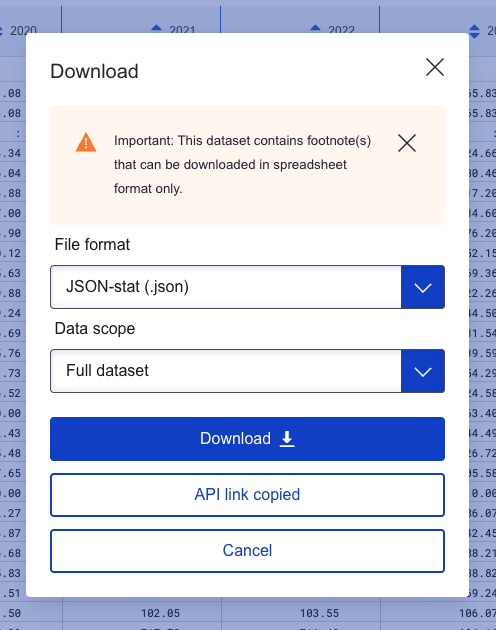

https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/apro_cpsh1/1.0?compress=false&format=json&lang=en

SDMX yes, but yields JSON/CSV/XML.

-> Filter: crop=C1100, unit=YLD, geo starts with DE

In [45]:
# NOTE: compress=false
# EUROSTAT_APRO_CPSH1_JSON = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/apro_cpsh1/1.0?compress=false&format=json&lang=en"
# EUROSTAT_APRO_CPSH1_TSV = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/apro_cpsh1/1.0?compress=false&format=tsv"
# EUROSTAT_APRO_CPSH1_CSV = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/apro_cpsh1/1.0?compress=false&format=csvdata&formatVersion=2.0&lang=en&labels=name"
# EUROSTAT_APRO_CPSH1_XML = (
#     "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/apro_cpsh1/1.0?compress=false"
# )

In [46]:
# NOTE: The one above is not NUTS2 based, this one is:
# Table view: https://ec.europa.eu/eurostat/databrowser/view/apro_cpshr/default/table?lang=en&category=agr.apro.apro_crop.apro_cp.apro_cpsh

EUROSTAT_APRO_CPSHR_CSV = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/apro_cpshr/1.0?compress=false&format=csvdata&formatVersion=2.0&lang=en&labels=name"

In [47]:
resp = requests.get(EUROSTAT_APRO_CPSHR_CSV)
resp.content[:1024]

b'STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,crops,Crops,strucpro,Structure of production,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)\r\ndataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUTS 2 region,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2000,,519.30,,,,,\r\ndataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUTS 2 region,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2001,,400.60,,,,,\r\ndataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUTS 2 region,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2002,,395.60,,,,,\r\ndataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUTS 2 region,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2003,,399.30,,,,,\r\ndataflow,ESTAT:APRO_CPSHR(1.0),Crop production in

In [48]:
import io

# Expected: 1534861 rows × 19 columns
eurostat_apro_cpshr_df = pd.read_csv(
    io.BytesIO(resp.content),
    # EUROSTAT_APRO_CPSHR_CSV,
    low_memory=False,
    # usecols=["TIME_PERIOD", "geo", "Crops", "OBS_VALUE", "OBS_FLAG"],
    # usecols=[6,9],
    # header=0,
    # names=["year", "region", "crops", "yield_t_ha", "obs_status"],
    # dtype={"obs_status": "category"},
    # index_col=["year", "region"],
    # parse_dates=["year"],
)
eurostat_apro_cpshr_df

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,crops,Crops,strucpro,Structure of production,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2000,NaN,519.30,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2001,NaN,400.60,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2002,NaN,395.60,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2003,NaN,399.30,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,ARA,Arable land,MA,Main area (1000 ha),AL,Albania,2004,NaN,384.80,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1534856,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,W1000,Grapes,PR_HU_EU,Harvested production in EU standard humidity (...,XK,Kosovo*,2020,NaN,26.33,NaN,NaN,NaN,NaN,NaN
1534857,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,W1000,Grapes,PR_HU_EU,Harvested production in EU standard humidity (...,XK,Kosovo*,2021,NaN,26.53,NaN,NaN,NaN,NaN,NaN
1534858,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,W1000,Grapes,PR_HU_EU,Harvested production in EU standard humidity (...,XK,Kosovo*,2022,NaN,23.51,NaN,NaN,NaN,NaN,NaN
1534859,dataflow,ESTAT:APRO_CPSHR(1.0),Crop production in EU standard humidity by NUT...,A,Annual,W1000,Grapes,PR_HU_EU,Harvested production in EU standard humidity (...,XK,Kosovo*,2023,NaN,9.71,NaN,NaN,NaN,NaN,NaN


In [49]:
eurostat_apro_cpshr_df[eurostat_apro_cpshr_df["geo"].str.startswith("DE")][
    ["geo", "Geopolitical entity (reporting)"]
].value_counts()

geo   Geopolitical entity (reporting)
DE    Germany                            5532
DE2   Bayern                             2856
DEG   Thüringen                          2855
DEB   Rheinland-Pfalz                    2850
DEE   Sachsen-Anhalt                     2850
DED   Sachsen                            2842
DE7   Hessen                             2836
DE1   Baden-Württemberg                  2834
DE4   Brandenburg                        2829
DEA   Nordrhein-Westfalen                2822
DE8   Mecklenburg-Vorpommern             2819
DEC   Saarland                           2814
DEF   Schleswig-Holstein                 2811
DE9   Niedersachsen                      2810
DE3   Berlin                             2637
DE6   Hamburg                            2628
DE5   Bremen                             2545
DEG0  Thüringen                          1511
DEC0  Saarland                           1507
DE80  Mecklenburg-Vorpommern             1506
DEF0  Schleswig-Holstein                 1

## 5. Synthesis: What the Package Needs

From the exploration above we can now read off the package design:

### Inferred schema (`WEATHER_DAILY_COLUMNS`)

The pipeline can't talk to DWD, SoilGrids, or Eurostat directly for ML training - the data must be preprocessed in preparation.
DWD is station-based; we need a spatial aggregation step (nearest-station or kriging) before the data enters the pipeline.
This is why `dwd_parse.py` only reads a **pre-processed CSV** with columns already aligned to the internal schema.

### Inferred `soil_demo.py`

SoilGrids centroid queries work as a prototype but are not robust for large regions.
The real soil integration step performs zonal statistics (raster→polygon) with `rasterio` + `geopandas`.
For the demo we bypass this with `make_demo_soil()` which generates synthetic values consistent with the known high-sand character of Brandenburg.

### Inferred `config.py` values

Config field | Source | Value
--|---|---
`season.start_month/day` | Agronomy (winter wheat sowing) | Oct 1
`season.end_month/day` | Harvest (typical NE Germany) | Jul 31
`tbase_c` | Wheat GDD threshold | 5°C
`sand_threshold_pct` | SoilGrids distribution for DE | 60%
`baseline_years` | > natural climate variability | 5

### What still needs real-data integration

```
ingest/
  dwd_parse.py           ← reads pre-processed regional daily CSV  ✓ schema defined
  soil_ingest.py         ← TODO: rasterio zonal stats on SoilGrids
  eurostat_yields.py     ← TODO: apro_cpsh1 → yields CSV

spatial/
  station_to_region.py   ← TODO: spatial join DWD stations → NUTS polygons
```

In [50]:
# Validate our synthetic daily data against the package's own schema contract
import sys

sys.path.insert(0, str(Path("../packages/agri_yield_drivers/src").resolve()))

from agri_yield_drivers.io.schemas import WEATHER_DAILY_COLUMNS

missing_cols = WEATHER_DAILY_COLUMNS - set(demo_daily.columns)
extra_cols = set(demo_daily.columns) - WEATHER_DAILY_COLUMNS

print(f"Required columns : {sorted(WEATHER_DAILY_COLUMNS)}")
print(f"Present in demo  : {sorted(demo_daily.columns)}")
print(f"Missing          : {sorted(missing_cols) or 'none ✓'}")
print(f"Extra            : {sorted(extra_cols) or 'none'}")
print()
print("Schema valid:", not missing_cols)

# Quick sanity stats
print(f"\nPrecip NaN rate : {demo_daily['precip_mm'].isna().mean():.1%}")
print(f"Precip zero rate: {(demo_daily['precip_mm'] == 0).mean():.1%}")
print(f"Tmean range     : {demo_daily['tmean_c'].min():.1f} – {demo_daily['tmean_c'].max():.1f} °C")


Required columns : ['date', 'precip_mm', 'region_id', 'tmean_c']
Present in demo  : ['date', 'precip_mm', 'region_id', 'tmean_c']
Missing          : none ✓
Extra            : none

Schema valid: True

Precip NaN rate : 0.0%
Precip zero rate: 39.0%
Tmean range     : -7.7 – 19.4 °C


In [51]:
# End-to-end smoke test: feed our notebook-constructed schema into the actual pipeline
from agri_yield_drivers.features.weather_indices import SeasonSpec, assign_season, compute_region_season_weather_indices
from agri_yield_drivers.config import Config

cfg = Config()

# Build season windows for the years in demo_daily
years_present = sorted({d.year if d.month >= 8 else d.year for d in demo_daily["date"] if hasattr(d, "year")})
season_windows = [
    SeasonSpec(season_year=y, start=cfg.season.start_date(y), end=cfg.season.end_date(y))
    for y in [2023]  # one season in our demo range
]

daily_assigned = assign_season(demo_daily, season_windows=season_windows)
print(f"Rows with season assigned: {daily_assigned['season_year'].notna().sum()} / {len(daily_assigned)}")

wx = compute_region_season_weather_indices(
    daily_assigned.dropna(subset=["season_year"]),
    tbase_c=cfg.weather.tbase_c,
    dry_spell_threshold_mm=cfg.weather.dry_spell_threshold_mm,
    max_missing_day_frac=cfg.weather.max_missing_day_frac,
)
print("\nWeather indices from notebook-constructed data:")
wx[["region_id", "season_year", "precip_total_mm", "gdd", "dry_spell_days", "coverage_day_frac"]]


Rows with season assigned: 912 / 912

Weather indices from notebook-constructed data:


,region_id,season_year,precip_total_mm,gdd,dry_spell_days,coverage_day_frac
0,DE-BB,2023,447.0,965.31,10,1.0
1,DE-BE,2023,517.3,957.42,12,1.0
2,DE-ST,2023,417.1,963.55,10,1.0


## Takeaways

### What worked

- **Eurostat GISCO** is the right boundary source - NUTS IDs join directly to yield stats, lightweight GeoJSON, no auth required.
- **DWD CDC** has great coverage for our focus states (~128 stations in Berlin/Brandenburg/Saxony-Anhalt). The raw station data is well-documented and freely accessible.
- **SoilGrids REST API** exists and returns structured JSON, so it's a viable starting point. The 250m raster product is a proper path for production.

### What didn't work (dead ends)

- **GADM** - arbitrary IDs, no NUTS codes, huge downloads. Not usable for EU statistical joins.
- **`wetterdienst` package** - 15+ transitive deps, SQLite cache requirement. Way too heavy for batch CSV ingest; however, stays in sync with upstream changes, assuming upstream maintenance.
- **Hardcoding DWD zip URLs** - filenames change when DWD publishes new data. Need directory scraping or a wrapper; hence some overhead.
- **SoilGrids centroid queries** - returned `null` for all three demo centroids. Maybe a coverage gap, maybe an API issue. Either way, can't rely on it.
- **Eurostat API v1 vs v2** - parameter names are incompatible across versions. Got a `400 Bad Request` before realizing the URL structure changed silently. v2 API works well though and is a viable source.

### Design decisions this exploration informed

1. The pipeline expects **pre-processed regional daily CSV** as input - not raw station data. The spatial aggregation (station -> region) is left as an explicit integration point.
2. Soil data uses **literature fallback values** in this exploratory mode. Real mode should use rasterio zonal stats on the SoilGrids GeoTIFF.
3. Yield data in this mode is **synthetic** - seeded, deterministic, consistent with the stress interaction the model tests for. Real integration should pull from Eurostat v2 API.

### Next steps

- [ ] Deeper analysis of data sources.
- [ ] Ingest an initial data catalog.
- [ ] Begin implementation of ingestion pipeline.